In [ ]:
from google.colab import drive #1
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os #2
DRIVE_BASE  = '/content/drive/MyDrive/cptac_gigatime'
WSI_DIR     = f'{DRIVE_BASE}/wsi_raw'
SCORES_DIR  = f'{DRIVE_BASE}/scores'       # ADD THIS
RESULTS_DIR = f'{DRIVE_BASE}/results'      # ADD THIS

for d in [DRIVE_BASE, WSI_DIR, SCORES_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

In [ ]:
# Install all dependencies #3
!pip install idc-index -q --upgrade
!pip install -q wsidicom albumentations huggingface_hub
!apt-get install -y -q openslide-tools libopenjp2-7

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.1/74.1 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.0/243.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.3 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
libopenjp2-7 is already the newest version (2.4.0-6ubuntu0.4).
libopenjp2-7 set to manually installed.
Suggested packages:
  libtiff-tools
The following NEW packages will be installed:
  libopenslide0 openslide-tools
0 upgraded, 2 newly installed, 0 to remove and 42 not upgraded.
Need to get 104 kB of archives.
After this operation, 297 kB of additional disk space wil

# Acces data NCI Imaging Data Commons

In [ ]:
# Connect to IDC and query CPTAC slides #4
from idc_index import IDCClient

client = IDCClient()
print("IDC version:", client.get_idc_version())

query = """
SELECT PatientID, collection_id, StudyInstanceUID,
       SeriesInstanceUID, Modality, series_size_MB
FROM index
WHERE Modality = 'SM'
  AND collection_id IN ('CPTAC', 'cptac_pda')
"""
df = client.sql_query(query)
print(f"Found {len(df)} series, {df['PatientID'].nunique()} patients")

IDC version: v23
Found 557 series, 168 patients


# Download slides

In [ ]:
# Download all patients in batches (crash-safe) #5
import json
from tqdm.notebook import tqdm

WSI_DIR      = f'{DRIVE_BASE}/wsi_raw'
PROGRESS_FILE = f'{DRIVE_BASE}/download_progress.json'
os.makedirs(WSI_DIR, exist_ok=True)

# Load progress (safe to re-run if Colab crashes)
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE) as f:
        done = set(json.load(f))
    print(f"Resuming — {len(done)} patients already downloaded")
else:
    done = set()

all_patients = df['PatientID'].unique().tolist()
todo         = [p for p in all_patients if p not in done]
print(f"Remaining: {len(todo)} patients")

for patient_id in tqdm(todo, desc="Patients"):
    try:
        client.download_from_selection(
            patientId=patient_id,
            downloadDir=WSI_DIR,
            show_progress_bar=False   # individual bars get messy in a loop
        )
        done.add(patient_id)

        # Save progress after every patient
        with open(PROGRESS_FILE, 'w') as f:
            json.dump(list(done), f)

    except Exception as e:
        print(f"  Failed {patient_id}: {e}")

print(f"\nDone! {len(done)}/{len(all_patients)} patients downloaded")

Remaining: 168 patients


Patients:   0%|          | 0/168 [00:00<?, ?it/s]


Done! 168/168 patients downloaded


In [ ]:
# Check folder structure after download #6
import os, glob

WSI_DIR = f'{DRIVE_BASE}/wsi_raw'

# idc-index saves as: wsi_raw/cptac_pda/PatientID/StudyUID/SM_SeriesUID/
dcm_files = glob.glob(f'{WSI_DIR}/**/*.dcm', recursive=True)
patients_on_disk = set(p.split('/')[-4] for p in dcm_files)  # PatientID level

print(f"DICOM files on disk : {len(dcm_files):,}")
print(f"Patients on disk    : {len(patients_on_disk)}")
print(f"\nSample paths:")
for f in dcm_files[:3]:
    print(f"  {f.replace(DRIVE_BASE, '.')}")

DICOM files on disk : 103,556
Patients on disk    : 168

Sample paths:
  ./wsi_raw/cptac_pda/C3N-03211/2.25.118888040877245471960162421573171616149/SM_1.3.6.1.4.1.5962.99.1.277576063.1997007629.1640955115903.2.0/45ab36a4-15af-4589-b6a9-6d7fe89aa68d.dcm
  ./wsi_raw/cptac_pda/C3N-03211/2.25.118888040877245471960162421573171616149/SM_1.3.6.1.4.1.5962.99.1.277576063.1997007629.1640955115903.2.0/07d13504-9d69-4064-80e1-3043797e9484.dcm
  ./wsi_raw/cptac_pda/C3N-03211/2.25.118888040877245471960162421573171616149/SM_1.3.6.1.4.1.5962.99.1.277576063.1997007629.1640955115903.2.0/0db1143b-3c7e-477b-80f7-cee6a0f386e7.dcm


Found 1850 series across 168 patients

Opening: C3N-03211
Dir: /content/drive/MyDrive/cptac_gigatime/wsi_raw/cptac_pda/C3N-03211/2.25.118888040877245471960162421573171616149/SM_1.3.6.1.4.1.5962.99.1.277576063.1997007629.1640955115903.2.0
Slide levels : 3
Base size    : Size(width=21911, height=15231)


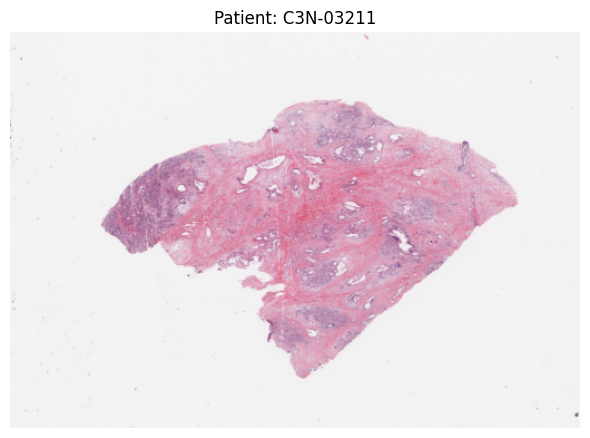

In [ ]:
# Open one slide and visualize thumbnail #7
from wsidicom import WsiDicom   # <-- import the class directly
from PIL import Image
import matplotlib.pyplot as plt

def find_series_dirs(wsi_dir):
    series_dirs = []
    for root, dirs, files in os.walk(wsi_dir):
        if any(f.endswith('.dcm') for f in files):
            parts = root.replace(wsi_dir+'/', '').split('/')
            patient_id = parts[1] if len(parts) > 1 else 'unknown'
            series_dirs.append((patient_id, root))
    return series_dirs

series_list = find_series_dirs(WSI_DIR)
print(f"Found {len(series_list)} series across {len(set(p for p,_ in series_list))} patients")

# Open first series
patient_id, test_dir = series_list[0]
print(f"\nOpening: {patient_id}")
print(f"Dir: {test_dir}")

wsi = WsiDicom.open(test_dir)   # <-- fixed
print(f"Slide levels : {len(wsi.levels)}")
print(f"Base size    : {wsi.levels.base_level.size}")

# Thumbnail
thumb = wsi.read_thumbnail(size=(512, 512))
plt.figure(figsize=(6, 6))
plt.imshow(thumb)
plt.title(f"Patient: {patient_id}")
plt.axis('off')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/thumb_{patient_id}.png', dpi=100)
plt.show()
wsi.close()